# Event Detail Extraction — Single Event Walkthrough

Steps through the full pipeline for one catchment, one ensemble member, one year, and one event. Mirrors the logic in `extract_event_details.py` with outputs and plots at each stage.

Useful for debugging, validating outputs, and understanding what each function in `functions_clean` produces.

## 0. Imports & config

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import cftime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from functions_clean import (
    get_rainfall_event_details,
    get_rainfall_cube,
    mask_cube_with_catchment_full_grid,
    subset_cube_to_bbox,
    find_max_precip_location,
    get_data_at_peak_cell,
    find_temporal_profile,
)

In [2]:
# ── Edit these to select your example ────────────────────────────────────────
CATCHMENT_NUM = "1"        # HA_NUM as string
ENS_NUM       = "01"       # Ensemble member ID
TARGET_YEAR   = 2020       # Year to load
TARGET_EVENT  = 1          # Event number (1-indexed within the CSV)

# ── Paths — mirror extract_event_details.py ───────────────────────────────
MOLLY_DIR_FF     = "/scratch/hydro4/users/kv25483/FutureFlood/"
RAINFALL_CSV_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/"
RAINFALL_CUBE_DIR = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ENS_NUM}/"

SHAPEFILE_PATH   = MOLLY_DIR_FF + "Data/CatchmentShapefiles/hyd_areas_GB_with_subcatchments.shp"
LOOKUP_CSV_PATH  = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/CEH_catchments/CEH_IHU_with_coastline/hyd_areas_GB_with_subcatchments_no_spaces.csv"

## 1. Load catchment boundary

In [3]:
catchments       = gpd.read_file(SHAPEFILE_PATH)
catchment_lookup = pd.read_csv(LOOKUP_CSV_PATH)
catchment_lookup_dict = dict(zip(catchment_lookup["HA_NUM"], catchment_lookup["HA_NAME"]))

CATCHMENT_NAME  = catchment_lookup_dict[CATCHMENT_NUM]
boundary_gdf    = catchments[catchments['HA_NUM'] == CATCHMENT_NUM]
CATCHMENT_POLY  = boundary_gdf.geometry.iloc[0]

print(f"Catchment: {CATCHMENT_NAME} (HA_NUM={CATCHMENT_NUM})")
print(f"Bounds: {CATCHMENT_POLY.bounds}")

Catchment: WickGroup (HA_NUM=1)
Bounds: (291625.00088116154, 917488.2936298568, 338953.99970787764, 970674.9975413242)


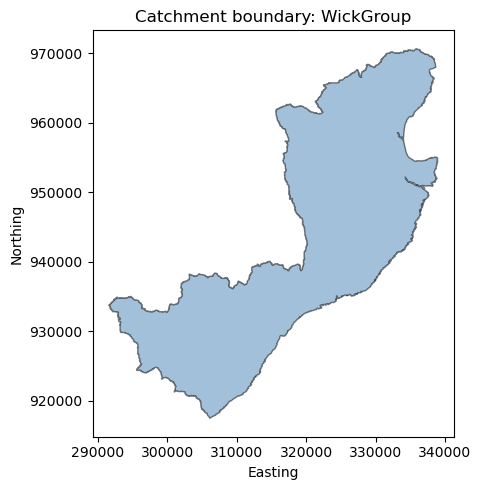

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
boundary_gdf.plot(ax=ax, facecolor='steelblue', edgecolor='black', alpha=0.5)
ax.set_title(f"Catchment boundary: {CATCHMENT_NAME}")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
plt.tight_layout()
plt.show()

## 2. Load rainfall events CSV & inspect

In [5]:
rainfall_events = pd.read_csv(
    RAINFALL_CSV_DIR + f"{CATCHMENT_NAME}_{ENS_NUM}_full_events_with_event_nums.csv")
rainfall_events['event_num'] = range(1, len(rainfall_events) + 1)

print(f"Total events: {len(rainfall_events)}")
rainfall_events.head(10)

Total events: 6


,start_indices,stop_indices,event_durations,peaks,start_year,start_month,start_day,start_hour,start_time,stop_time,start_time_seconds,stop_time_seconds,event_vol,max_extent,acc_total,acc_3hr,acc_6hr,acc_12hr,acc_24hr,event_num
0,6537,6563,26,30.27798,2051,9,3,8,705656.5,705682.5,2540363400,2540457000,647.765435,10,647.765435,238.57147,368.845870,534.508900,645.578117,1
1,6538,6550,12,36.48450,2058,9,3,9,766137.5,766149.5,2758095000,2758138200,333.429060,9,333.429060,217.62750,330.984530,333.358004,NaN,2
2,4741,4752,11,33.32302,2060,6,18,12,781620.5,781631.5,2813833800,2813873400,240.228876,7,240.228876,212.56825,237.083917,240.228876,NaN,3
3,7568,7593,25,33.20616,2061,10,16,7,793087.5,793112.5,2855115000,2855205000,578.005272,17,578.005272,331.12157,446.359540,524.021522,574.447261,4
4,6306,6325,19,31.67046,2075,8,23,17,912785.5,912804.5,3286027800,3286096200,407.027607,9,407.027607,156.34759,201.488320,385.709114,NaN,5
5,5774,5783,9,34.25895,2079,8,1,13,946813.5,946822.5,3408528600,3408561000,136.112320,9,136.112320,131.79377,136.111739,NaN,NaN,6


In [6]:
# Build event details cache and add year column — mirrors the main script
event_details_cache = {
    ev: get_rainfall_event_details(rainfall_events, ev)
    for ev in rainfall_events['event_num']
}
rainfall_events['year'] = rainfall_events['event_num'].map(
    lambda ev: event_details_cache[ev]['yr'])

# Inspect the target event
event_details = event_details_cache[TARGET_EVENT]
print(f"\nEvent {TARGET_EVENT} details:")
for k, v in event_details.items():
    print(f"  {k}: {v}")


Event 1 details:
  event_num: 1
  yr: 2051
  start_idx: 6537
  stop_idx: 6563
  max_precip_from_csv: 30


## 3. Load rainfall cube & create catchment mask

In [7]:
# Load cube for target year
year_cube_full = get_rainfall_cube(TARGET_YEAR, ENS_NUM, RAINFALL_CUBE_DIR)
print(f"Full cube shape (T, Y, X): {year_cube_full.shape}")
print(year_cube_full)

Full cube shape (T, Y, X): (8640, 244, 180)
lwe_precipitation_rate / (mm/hour)  (time: 8640; projection_y_coordinate: 244; projection_x_coordinate: 180)
    Dimension coordinates:
        time                             x                              -                             -
        projection_y_coordinate          -                              x                             -
        projection_x_coordinate          -                              -                             x
    Auxiliary coordinates:
        month_number                     x                              -                             -
        year                             x                              -                             -
        yyyymmddhh                       x                              -                             -
        latitude                         -                              x                             x
        longitude                        -                       

In [8]:
# Build the full-grid 2D mask (computed once per ensemble, reused across years)
FULL_MASK_2D = mask_cube_with_catchment_full_grid(
    year_cube_full[0], CATCHMENT_POLY, method='full_cell')

print(f"Mask shape: {FULL_MASK_2D.shape}")
print(f"Cells inside catchment: {FULL_MASK_2D.sum()} / {FULL_MASK_2D.size}")

Mask shape: (244, 180)
Cells inside catchment: 60 / 43920


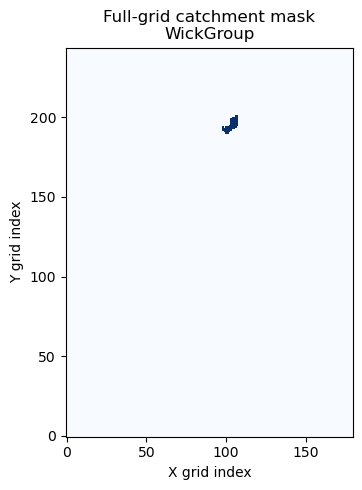

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(FULL_MASK_2D, origin='lower', cmap='Blues', interpolation='none')
ax.set_title(f"Full-grid catchment mask\n{CATCHMENT_NAME}")
ax.set_xlabel("X grid index")
ax.set_ylabel("Y grid index")
plt.tight_layout()
plt.show()

## 4. Subset cube to catchment bounding box

In [10]:
year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube_full, CATCHMENT_POLY, buffer=0)

print(f"Subsetted cube shape (T, Y, X): {year_cube.shape}")
print(f"Offsets into full grid — x: {x_offset}, y: {y_offset}")

nx_sub      = year_cube.shape[2]
ny_sub      = year_cube.shape[1]
mask_2d_sub = FULL_MASK_2D[y_offset:y_offset+ny_sub, x_offset:x_offset+nx_sub]

print(f"Subsetted mask shape: {mask_2d_sub.shape}")
print(f"Cells inside catchment (subsetted): {mask_2d_sub.sum()}")

Subsetted cube shape (T, Y, X): (8640, 12, 10)
Offsets into full grid — x: 98, y: 190
Subsetted mask shape: (12, 10)
Cells inside catchment (subsetted): 60


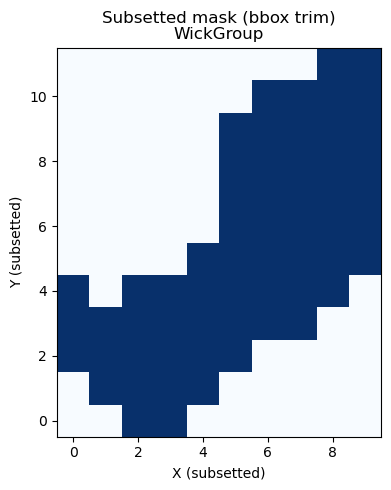

In [11]:
# Plot subsetted mask to confirm the bbox trim looks right
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(mask_2d_sub, origin='lower', cmap='Blues', interpolation='none')
ax.set_title(f"Subsetted mask (bbox trim)\n{CATCHMENT_NAME}")
ax.set_xlabel("X (subsetted)")
ax.set_ylabel("Y (subsetted)")
plt.tight_layout()
plt.show()

## 5. Inspect the event window in the cube

In [12]:
start_idx = event_details['start_idx']
stop_idx  = event_details['stop_idx']

event_slice = year_cube[start_idx:stop_idx, :, :]
print(f"Event window: timesteps {start_idx} → {stop_idx} ({stop_idx - start_idx} hours)")
print(f"Event slice shape: {event_slice.shape}")

# Total accumulated rainfall over the event
event_accum = np.nansum(event_slice.data, axis=0)
event_accum_masked = np.where(mask_2d_sub, event_accum, np.nan)

print(f"\nAccumulated rainfall over event (catchment cells only):")
print(f"  Max:  {np.nanmax(event_accum_masked):.2f} mm")
print(f"  Mean: {np.nanmean(event_accum_masked):.2f} mm")

Event window: timesteps 6537 → 6563 (26 hours)
Event slice shape: (26, 12, 10)

Accumulated rainfall over event (catchment cells only):
  Max:  0.06 mm
  Mean: 0.00 mm


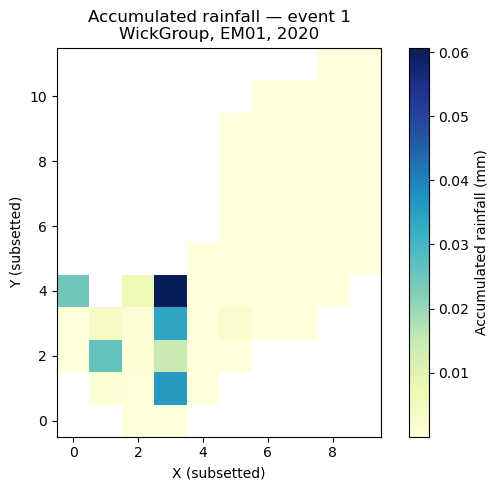

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(event_accum_masked, origin='lower', cmap='YlGnBu', interpolation='none')
plt.colorbar(im, ax=ax, label='Accumulated rainfall (mm)')
ax.set_title(f"Accumulated rainfall — event {TARGET_EVENT}\n"
             f"{CATCHMENT_NAME}, EM{ENS_NUM}, {TARGET_YEAR}")
ax.set_xlabel("X (subsetted)")
ax.set_ylabel("Y (subsetted)")
plt.tight_layout()
plt.show()

## 6. Find peak precipitation location

In [14]:
event_results = find_max_precip_location(
    year_cube, start_idx, stop_idx,
    x_offset=x_offset, y_offset=y_offset,
    mask_2d=mask_2d_sub
)

print("find_max_precip_location output:")
for k, v in event_results.items():
    print(f"  {k}: {v}")

Max precip: 0.05991661921143532
find_max_precip_location output:
  max_precip: 0.05991661921143532
  t_global: 6548
  x_idx: 3
  y_idx: 4
  x_idx_global: 101
  y_idx_global: 194
  x_coord: 307500.0
  y_coord: 937500.0


In [15]:
# Add metadata
event_results['ens']       = ENS_NUM
event_results['year']      = TARGET_YEAR
event_results['start_idx'] = start_idx
event_results['stop_idx']  = stop_idx

# Resolve peak day from time coordinate
time_coord = year_cube.coord('time')
t = time_coord.units.num2date(time_coord.points[event_results['t_global']])
event_results['rainfall_peak_day'] = cftime.Datetime360Day(t.year, t.month, t.day)
print(f"\nPeak rainfall day: {event_results['rainfall_peak_day']}")


Peak rainfall day: 2020-09-03 00:00:00


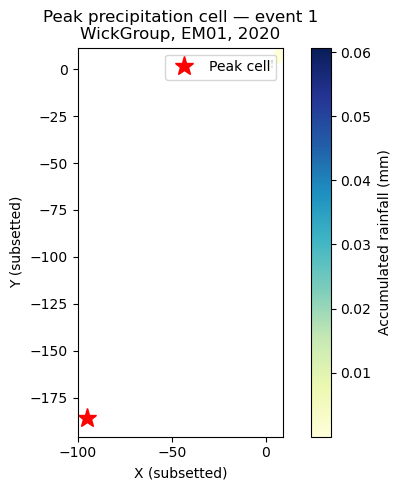

In [16]:
# Plot accumulated rainfall with peak cell marked
# Recover subsetted peak coordinates from the global offsets
peak_x_sub = event_results.get('x_global', event_results.get('x_idx')) - x_offset
peak_y_sub = event_results.get('y_global', event_results.get('y_idx')) - y_offset

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(event_accum_masked, origin='lower', cmap='YlGnBu', interpolation='none')
ax.plot(peak_x_sub, peak_y_sub, 'r*', markersize=14, label='Peak cell')
plt.colorbar(im, ax=ax, label='Accumulated rainfall (mm)')
ax.legend()
ax.set_title(f"Peak precipitation cell — event {TARGET_EVENT}\n"
             f"{CATCHMENT_NAME}, EM{ENS_NUM}, {TARGET_YEAR}")
ax.set_xlabel("X (subsetted)")
ax.set_ylabel("Y (subsetted)")
plt.tight_layout()
plt.show()

## 7. Extract temporal profile at peak cell

In [17]:
rainfall_at_peak = get_data_at_peak_cell(year_cube, event_results)

print(f"Time series length at peak cell: {len(rainfall_at_peak)} timesteps")
print(f"Max hourly rainfall at peak cell: {np.nanmax(rainfall_at_peak):.2f} mm/hr")

TypeError: object of type 'Cube' has no len()

In [ ]:
temp_profile_dict = find_temporal_profile(rainfall_at_peak, event_results, plot=False)

print("find_temporal_profile output:")
for k, v in temp_profile_dict.items():
    print(f"  {k}: {v}")

# Merge into final results dict
event_results = {**event_results, **temp_profile_dict}

In [ ]:
# Plot the hourly rainfall time series at the peak cell over the event window
event_ts = rainfall_at_peak[start_idx:stop_idx]
hours     = np.arange(len(event_ts))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hours, event_ts, color='steelblue', width=0.8)
ax.set_xlabel("Hour within event")
ax.set_ylabel("Rainfall (mm/hr)")
ax.set_title(f"Hourly rainfall at peak cell — event {TARGET_EVENT}\n"
             f"{CATCHMENT_NAME}, EM{ENS_NUM}, {TARGET_YEAR}")
plt.tight_layout()
plt.show()

## 8. Final results summary

In [ ]:
results_df = pd.DataFrame([event_results])
results_df